## Introduction

Brick kilns are a significant source of air pollution in India, and monitoring their temporal patterns across multiple locations is crucial for environmental management. Traditional approaches require manual inspection of satellite imagery, which becomes prohibitively slow when analyzing many locations.

In this notebook, we demonstrate **async parallel processing** of temporal satellite imagery using **Gemini 3 Pro's multi-image context capability**. We analyze **10 different locations** simultaneously, where each location has satellite images captured across multiple years (2014-2022).

**Key Features:**
1. **Multi-Image Context**: Each API call processes all years for one location in a single request
2. **Async Parallel Processing**: All 10 locations are analyzed concurrently using `asyncio`
3. **Structured Output**: JSON responses enable programmatic analysis and visualization
4. **Efficiency**: Dramatically faster than sequential processing (10 locations in ~30-40 seconds vs. 5+ minutes)

**Analysis Goals:**
- Identify when brick kilns first appear at each location
- Determine kiln types (FCBTK vs. Zig-zag) based on shape (oval vs. rectangular)
- Track changes in kiln count and configuration over time
- Compare temporal patterns across different locations

This approach combines the benefits of:
- **Server-side batching** (multi-image context per location)
- **Client-side parallelism** (async requests for multiple locations)

## Setup

In [19]:
import os
import glob
import re
import asyncio
import time
from collections import defaultdict
from google import genai
from PIL import Image
import matplotlib.pyplot as plt
import json
import numpy as np

# Initialize Gemini client
if 'GEMINI_API_KEY' not in os.environ:
    raise ValueError(
        "GEMINI_API_KEY not found in environment.\n"
        "Set it with: export GEMINI_API_KEY='your-key'\n"
        "Get your key at: https://aistudio.google.com/apikey"
    )

client = genai.Client(api_key=os.environ['GEMINI_API_KEY'])
MODEL = "models/gemini-3-pro-preview"

print(f"Gemini client initialized")
print(f"Using model: {MODEL}")

%config InlineBackend.figure_format = 'retina'

Gemini client initialized
Using model: models/gemini-3-pro-preview


## Load and Group Temporal Images by Location

In [20]:
# Get all brick kiln images
image_folder = "brick-kilns"
image_files = sorted(glob.glob(f"{image_folder}/*.png"))

print(f"Found {len(image_files)} images total")

# Parse filename to extract location and year
def parse_filename(filename):
    """Extract lat, lon, year from filename like 28.212481_77.401398_2014.png"""
    basename = os.path.basename(filename)
    parts = basename.replace('.png', '').split('_')
    lat, lon, year = float(parts[0]), float(parts[1]), int(parts[2])
    location_key = f"{lat}_{lon}"
    return {
        'lat': lat,
        'lon': lon,
        'year': year,
        'location_key': location_key,
        'path': filename
    }

# Group images by location
locations_data = defaultdict(list)
for f in image_files:
    data = parse_filename(f)
    locations_data[data['location_key']].append(data)

# Sort each location's images by year
for loc_key in locations_data:
    locations_data[loc_key] = sorted(locations_data[loc_key], key=lambda x: x['year'])

print(f"\nFound {len(locations_data)} unique locations:")
for i, (loc_key, images) in enumerate(list(locations_data.items())[:10], 1):
    sample = images[0]
    years = [img['year'] for img in images]
    print(f"  {i}. {sample['lat']:.6f}°N, {sample['lon']:.6f}°E - {len(images)} years: {years}")

Found 50 images total

Found 10 unique locations:
  1. 28.208668°N, 77.420208°E - 5 years: [2014, 2016, 2018, 2020, 2022]
  2. 28.212481°N, 77.401398°E - 5 years: [2014, 2016, 2018, 2020, 2022]
  3. 28.215068°N, 77.424273°E - 5 years: [2014, 2016, 2018, 2020, 2022]
  4. 28.216044°N, 77.399816°E - 5 years: [2014, 2016, 2018, 2020, 2022]
  5. 28.219114°N, 77.422602°E - 5 years: [2014, 2016, 2018, 2020, 2022]
  6. 28.219207°N, 77.393943°E - 5 years: [2014, 2016, 2018, 2020, 2022]
  7. 28.220388°N, 77.416754°E - 5 years: [2014, 2016, 2018, 2020, 2022]
  8. 28.223407°N, 77.382953°E - 5 years: [2014, 2016, 2018, 2020, 2022]
  9. 28.224213°N, 77.381653°E - 5 years: [2014, 2016, 2018, 2020, 2022]
  10. 28.225187°N, 77.548923°E - 5 years: [2014, 2016, 2018, 2020, 2022]


### Visualize Sample Location

Let's visualize one sample location to see the temporal sequence before processing all locations:

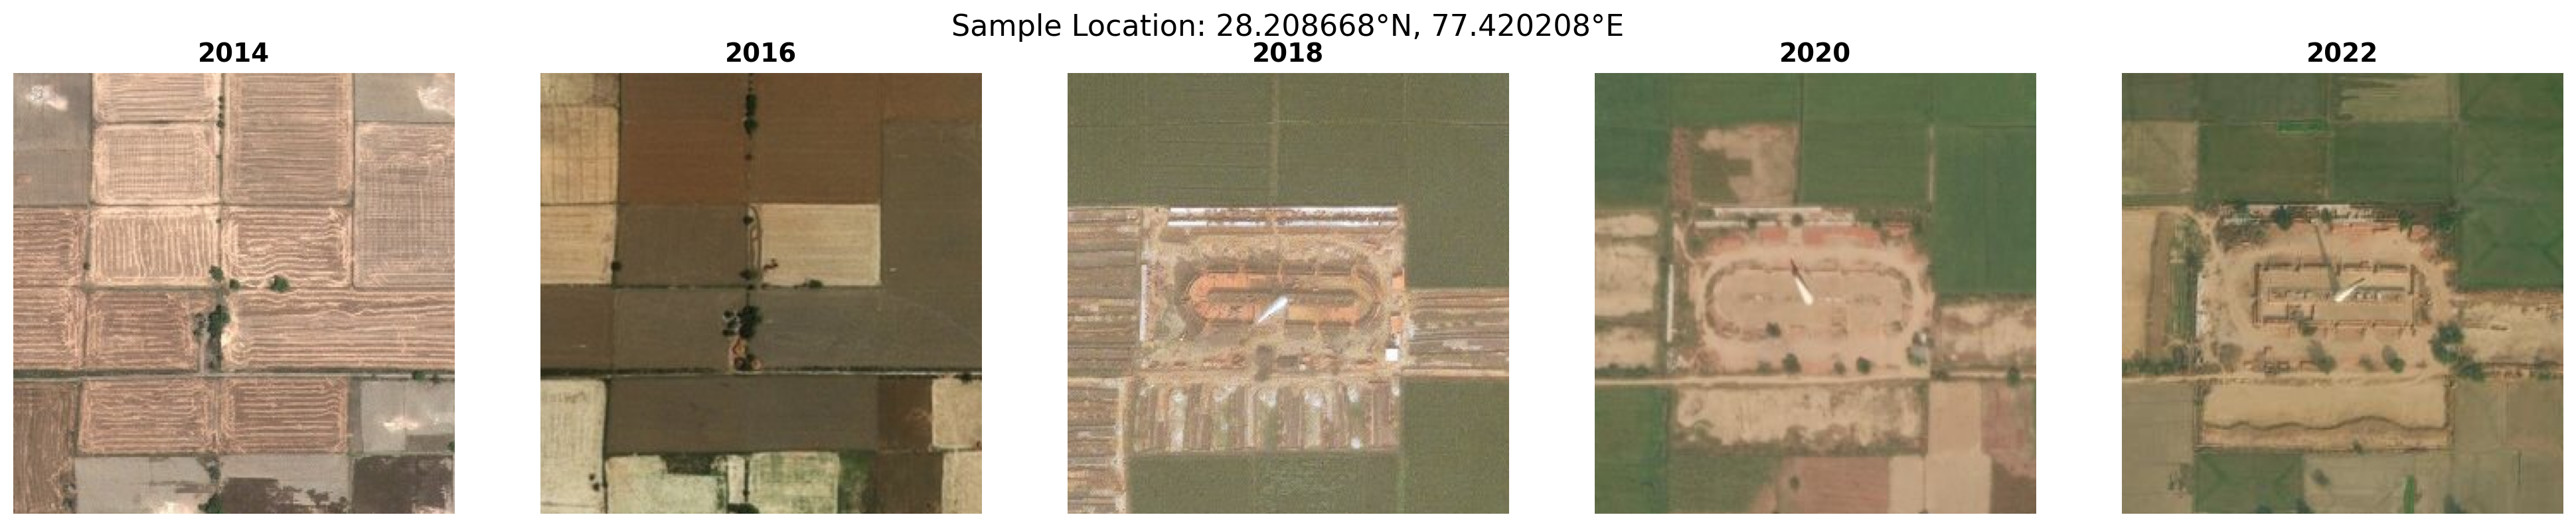

In [21]:
# Visualize one sample location
sample_location = list(locations_data.values())[0]
sample_images = [Image.open(img['path']) for img in sample_location]
sample_years = [img['year'] for img in sample_location]
sample_lat = sample_location[0]['lat']
sample_lon = sample_location[0]['lon']

fig, axes = plt.subplots(1, len(sample_images), figsize=(4*len(sample_images), 4))

for ax, img, year in zip(axes, sample_images, sample_years):
    ax.imshow(img)
    ax.set_title(f"{year}", fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle(f"Sample Location: {sample_lat:.6f}°N, {sample_lon:.6f}°E", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## Async Multi-Location Processing

Now we'll process all 10 locations in parallel using `asyncio`. Each location sends all its years in a single API call (multi-image context), and all locations are processed concurrently.

In [24]:
# Run async processing for all 10 locations
print("="*80)
print(f"PROCESSING {len(locations_data)} LOCATIONS IN PARALLEL")
print("="*80)
print("\nStarting async batch processing...\n")

start_time = time.time()

# Run the async processing
all_results = await process_all_locations(locations_data)

elapsed_time = time.time() - start_time

print(f"\n{'='*80}")
print(f"✓ All {len(all_results)} locations processed in {elapsed_time:.2f} seconds")
print(f"  Average: {elapsed_time/len(all_results):.2f} seconds per location")
print(f"  Speedup vs sequential (~35s each): {(35*len(all_results))/elapsed_time:.1f}x faster")
print(f"{'='*80}")

PROCESSING 10 LOCATIONS IN PARALLEL

Starting async batch processing...

  [1] Processing 28.208668°N, 77.420208°E...
  [2] Processing 28.212481°N, 77.401398°E...
  [3] Processing 28.215068°N, 77.424273°E...
  [4] Processing 28.216044°N, 77.399816°E...
  [5] Processing 28.219114°N, 77.422602°E...
  [6] Processing 28.219207°N, 77.393943°E...
  [7] Processing 28.220388°N, 77.416754°E...
  [8] Processing 28.223407°N, 77.382953°E...
  [9] Processing 28.224213°N, 77.381653°E...
  [10] Processing 28.225187°N, 77.548923°E...
  [7] ✓ Completed 28.220388°N, 77.416754°E
  [5] ✓ Completed 28.219114°N, 77.422602°E
  [9] ✓ Completed 28.224213°N, 77.381653°E
  [4] ✓ Completed 28.216044°N, 77.399816°E
  [2] ✓ Completed 28.212481°N, 77.401398°E
  [1] ✓ Completed 28.208668°N, 77.420208°E
  [3] ✓ Completed 28.215068°N, 77.424273°E
  [8] ✓ Completed 28.223407°N, 77.382953°E
  [10] ✓ Completed 28.225187°N, 77.548923°E
  [6] ✓ Completed 28.219207°N, 77.393943°E

✓ All 10 locations processed in 42.08 second

## Analysis Results Summary

In [25]:
# Display summary of all locations
print("\n" + "="*80)
print("SUMMARY: ALL LOCATIONS")
print("="*80)

successful = sum(1 for r in all_results if r['analysis'] is not None)
print(f"\n✓ Successfully parsed: {successful}/{len(all_results)} locations\n")

for i, result in enumerate(all_results, 1):
    print(f"\nLocation {i}: {result['location_str']}")
    print("-" * 60)
    
    if result['analysis']:
        analysis = result['analysis']
        first_year = analysis.get('first_year', 'Unknown')
        evolution = analysis.get('evolution', 'N/A')
        
        print(f"  First Appearance: {first_year}")
        print(f"  Evolution: {evolution[:100]}...")
        
        # Show type changes
        year_data = analysis.get('years', [])
        if year_data:
            types_seen = [y.get('type', 'None') for y in year_data if y.get('has_kilns')]
            unique_types = list(dict.fromkeys(types_seen))  # Preserve order
            if unique_types:
                print(f"  Types observed: {' → '.join(unique_types)}")
    else:
        print(f"  ⚠ Failed to parse analysis")

print("\n" + "="*80)


SUMMARY: ALL LOCATIONS

✓ Successfully parsed: 10/10 locations


Location 1: 28.208668°N, 77.420208°E
------------------------------------------------------------
  First Appearance: 2018
  Evolution: The site transformed from agricultural land to an oval FCBTK in 2018. Between 2020 and 2022, the kil...
  Types observed: FCBTK → Zigzag

Location 2: 28.212481°N, 77.401398°E
------------------------------------------------------------
  First Appearance: 2018
  Evolution: The site transitioned from agricultural land (2014-2016) to an industrial brick kiln site in 2018. I...
  Types observed: FCBTK → Zigzag

Location 3: 28.215068°N, 77.424273°E
------------------------------------------------------------
  First Appearance: 2018
  Evolution: The site began as empty agricultural land in 2014 and 2016. In 2018, an oval-shaped FCBTK was establ...
  Types observed: FCBTK → Zigzag

Location 4: 28.216044°N, 77.399816°E
------------------------------------------------------------
  First Appear

In [ ]:
# Create a comprehensive visualization showing all locations with predictions
num_locations = len(all_results)
years = [2014, 2016, 2018, 2020, 2022]

# Create a MUCH larger figure with subplots for each location
# Increased from figsize=(20, 4*num_locations) to (30, 6*num_locations)
fig, axes = plt.subplots(num_locations, len(years), figsize=(30, 6*num_locations))

# Ensure axes is 2D array even for single location
if num_locations == 1:
    axes = axes.reshape(1, -1)

for loc_idx, result in enumerate(all_results):
    # Load images for this location
    location_data = locations_data[result['location_key']]
    
    for year_idx, year in enumerate(years):
        ax = axes[loc_idx, year_idx]
        
        # Find the image for this year
        img_data = next((img for img in location_data if img['year'] == year), None)
        
        if img_data:
            # Load and display image
            img = Image.open(img_data['path'])
            ax.imshow(img)
            
            # Get prediction for this year
            kiln_type = "None"
            if result['analysis']:
                year_data = result['analysis'].get('years', [])
                year_pred = next((y for y in year_data if y.get('year') == year), None)
                if year_pred:
                    kiln_type = year_pred.get('type', 'None')
            
            # Set title with year and predicted type - larger font
            title_color = 'green' if kiln_type in ['FCBTK', 'Zigzag'] else 'gray'
            ax.set_title(f"{year}\n{kiln_type}", fontsize=16, fontweight='bold', 
                        color=title_color, pad=10)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=14)
            ax.set_title(f"{year}\nNo data", fontsize=16)
        
        ax.axis('off')
    
    # Add location label on the left - larger font
    axes[loc_idx, 0].text(-0.12, 0.5, f"Location {loc_idx+1}\n{result['location_str']}", 
                          transform=axes[loc_idx, 0].transAxes,
                          fontsize=13, fontweight='bold', 
                          ha='right', va='center', rotation=0)

plt.suptitle('Temporal Analysis Results: All Locations with Predicted Kiln Types', 
             fontsize=24, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

In [31]:
# Install required packages for proper mapping
import subprocess
import sys

try:
    import geopandas as gpd
    import contextily as ctx
except ImportError:
    print("Installing geopandas and contextily for proper mapping...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "geopandas", "contextily", "-q"])
    import geopandas as gpd
    import contextily as ctx

print("Geospatial packages ready")

Geospatial packages ready


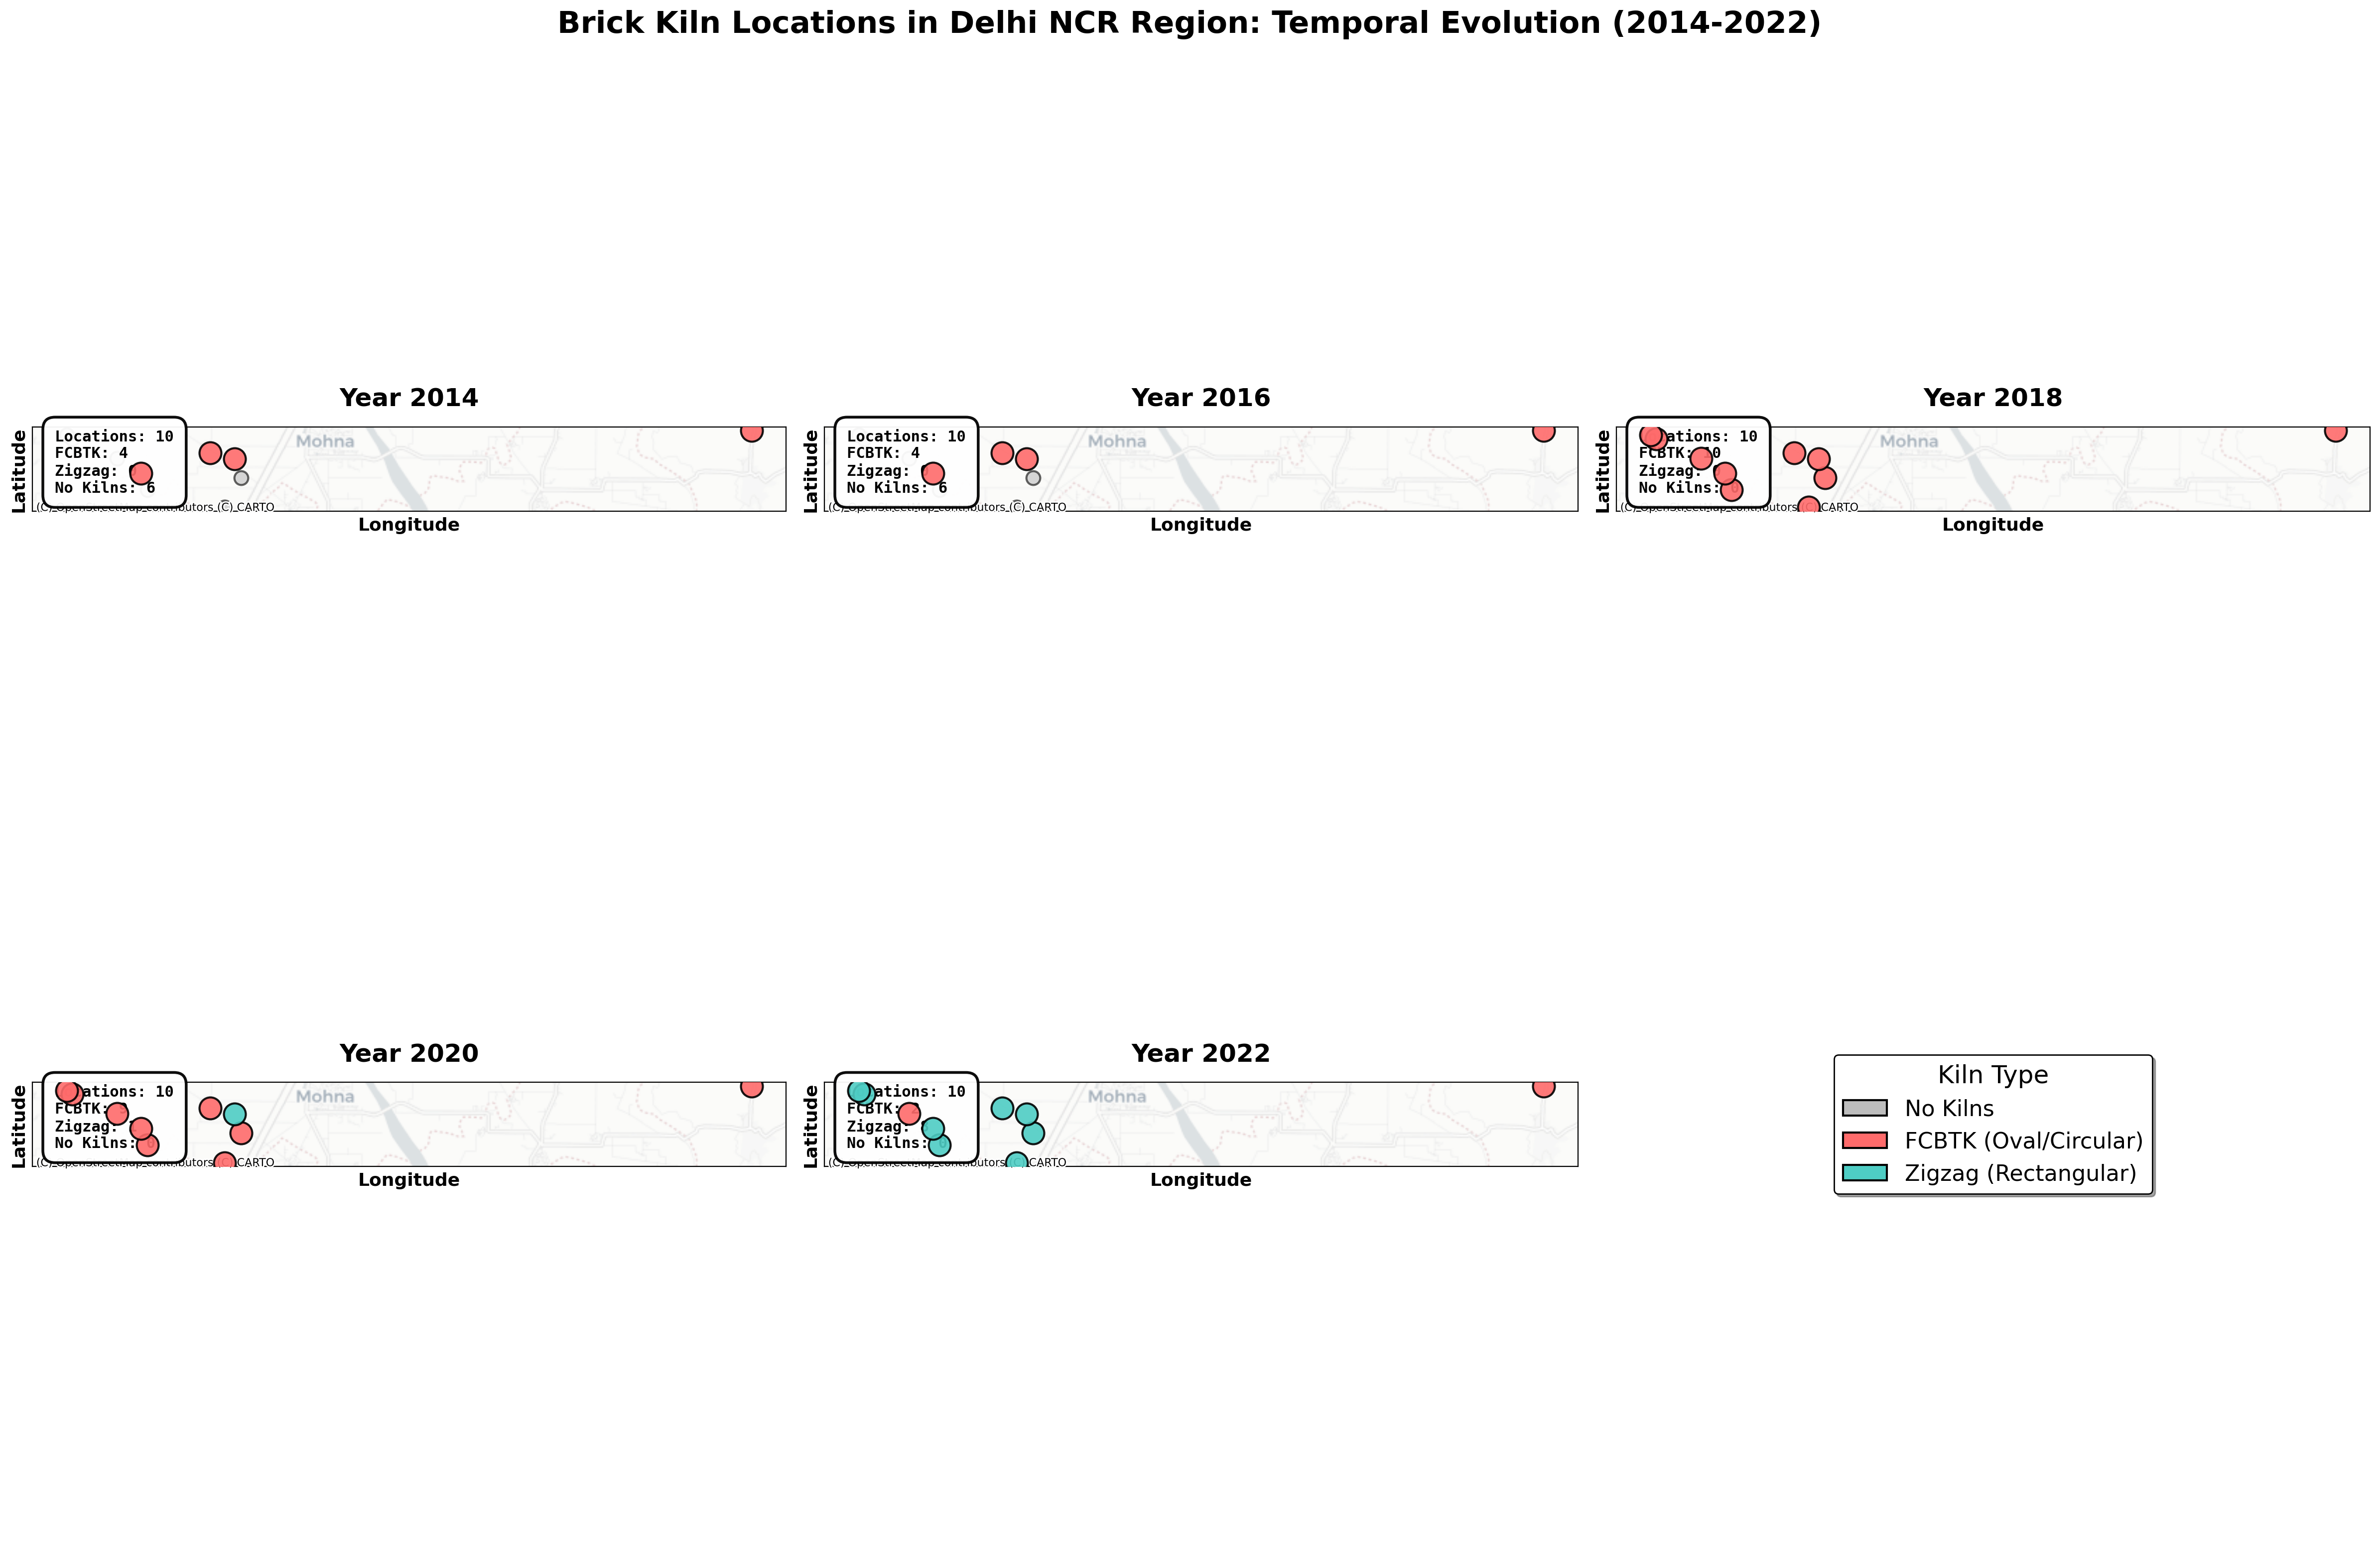

In [33]:
# Create beautiful maps with basemap for each year
import matplotlib.patches as mpatches
from shapely.geometry import Point

years = [2014, 2016, 2018, 2020, 2022]

# Define colors for each kiln type
color_map = {
    'None': '#BDBDBD',      # Gray
    'FCBTK': '#FF6B6B',     # Red/Coral
    'Zigzag': '#4ECDC4'     # Teal/Green
}

# Create a figure with subplots for each year
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
axes = axes.flatten()

for year_idx, year in enumerate(years):
    ax = axes[year_idx]
    
    # Prepare data for this year
    points = []
    kiln_types = []
    
    for result in all_results:
        if result['analysis']:
            lat = result['lat']
            lon = result['lon']
            
            # Find kiln type for this year
            year_data = result['analysis'].get('years', [])
            year_pred = next((y for y in year_data if y.get('year') == year), None)
            
            if year_pred:
                kiln_type = year_pred.get('type', 'None')
                points.append(Point(lon, lat))
                kiln_types.append(kiln_type)
    
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame({
        'geometry': points,
        'type': kiln_types
    }, crs='EPSG:4326')
    
    # Convert to Web Mercator for basemap
    gdf = gdf.to_crs(epsg=3857)
    
    # Plot each kiln type separately for better control
    for kiln_type in ['None', 'FCBTK', 'Zigzag']:
        subset = gdf[gdf['type'] == kiln_type]
        if len(subset) > 0:
            size = 100 if kiln_type == 'None' else 250
            alpha = 0.6 if kiln_type == 'None' else 0.9
            zorder = 3 if kiln_type == 'None' else 5
            
            subset.plot(ax=ax, color=color_map[kiln_type], markersize=size, 
                       alpha=alpha, edgecolor='black', linewidth=1.5, zorder=zorder)
    
    # Add basemap
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.8, zoom=12)
    except:
        # Fallback if basemap fails
        ax.set_facecolor('#f0f0f0')
    
    ax.set_xlabel('Longitude', fontsize=13, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=13, fontweight='bold')
    ax.set_title(f'Year {year}', fontsize=18, fontweight='bold', pad=15)
    ax.set_aspect('equal')
    
    # Remove axis ticks for cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Count kilns by type
    type_counts = {'FCBTK': 0, 'Zigzag': 0, 'None': 0}
    for kt in kiln_types:
        type_counts[kt] = type_counts.get(kt, 0) + 1
    
    # Add statistics box with better styling
    stats_text = f"Locations: {len(kiln_types)}\n"
    stats_text += f"FCBTK: {type_counts['FCBTK']}\n"
    stats_text += f"Zigzag: {type_counts['Zigzag']}\n"
    stats_text += f"No Kilns: {type_counts['None']}"
    
    ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, 
           fontsize=11, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.8', facecolor='white', 
                    alpha=0.95, edgecolor='black', linewidth=2),
           family='monospace')

# Remove the extra subplot
axes[-1].axis('off')

# Create legend with better styling
legend_elements = [
    mpatches.Patch(facecolor=color_map['None'], edgecolor='black', linewidth=1.5, 
                   label='No Kilns'),
    mpatches.Patch(facecolor=color_map['FCBTK'], edgecolor='black', linewidth=1.5,
                   label='FCBTK (Oval/Circular)'),
    mpatches.Patch(facecolor=color_map['Zigzag'], edgecolor='black', linewidth=1.5,
                   label='Zigzag (Rectangular)')
]
axes[-1].legend(handles=legend_elements, loc='center', fontsize=16, 
               title='Kiln Type', title_fontsize=18, frameon=True,
               facecolor='white', edgecolor='black', framealpha=1, 
               shadow=True)

plt.suptitle('Brick Kiln Locations in Delhi NCR Region: Temporal Evolution (2014-2022)', 
            fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [34]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from shapely.geometry import Point

# Prepare data for animation
years = [2014, 2016, 2018, 2020, 2022]
color_map = {
    'None': '#BDBDBD',      # Gray
    'FCBTK': '#FF6B6B',     # Red/Coral
    'Zigzag': '#4ECDC4'     # Teal/Green
}

# Pre-compute bounds for consistent view
all_lats = [r['lat'] for r in all_results]
all_lons = [r['lon'] for r in all_results]

# Create GeoDataFrame for bounds
temp_points = [Point(lon, lat) for lon, lat in zip(all_lons, all_lats)]
temp_gdf = gpd.GeoDataFrame(geometry=temp_points, crs='EPSG:4326')
temp_gdf = temp_gdf.to_crs(epsg=3857)
bounds = temp_gdf.total_bounds  # minx, miny, maxx, maxy

# Add margin
margin_x = (bounds[2] - bounds[0]) * 0.15
margin_y = (bounds[3] - bounds[1]) * 0.15
xlim = (bounds[0] - margin_x, bounds[2] + margin_x)
ylim = (bounds[1] - margin_y, bounds[3] + margin_y)

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 12))

def animate(frame_idx):
    ax.clear()
    year = years[frame_idx]
    
    # Prepare data for this year
    points = []
    kiln_types = []
    
    for result in all_results:
        if result['analysis']:
            lat = result['lat']
            lon = result['lon']
            
            # Find kiln type for this year
            year_data = result['analysis'].get('years', [])
            year_pred = next((y for y in year_data if y.get('year') == year), None)
            
            if year_pred:
                kiln_type = year_pred.get('type', 'None')
                points.append(Point(lon, lat))
                kiln_types.append(kiln_type)
    
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame({
        'geometry': points,
        'type': kiln_types
    }, crs='EPSG:4326')
    
    # Convert to Web Mercator
    gdf = gdf.to_crs(epsg=3857)
    
    # Plot each kiln type separately
    for kiln_type in ['None', 'FCBTK', 'Zigzag']:
        subset = gdf[gdf['type'] == kiln_type]
        if len(subset) > 0:
            size = 150 if kiln_type == 'None' else 350
            alpha = 0.6 if kiln_type == 'None' else 0.95
            zorder = 3 if kiln_type == 'None' else 5
            
            subset.plot(ax=ax, color=color_map[kiln_type], markersize=size, 
                       alpha=alpha, edgecolor='black', linewidth=2, zorder=zorder)
    
    # Add basemap
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.8, zoom=12)
    except:
        ax.set_facecolor('#f0f0f0')
    
    # Set consistent bounds
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    
    ax.set_xlabel('Longitude', fontsize=15, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=15, fontweight='bold')
    ax.set_title(f'Brick Kiln Distribution - Year {year}', 
                fontsize=20, fontweight='bold', pad=20)
    
    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Count kilns by type
    type_counts = {'FCBTK': 0, 'Zigzag': 0, 'None': 0}
    for kt in kiln_types:
        type_counts[kt] = type_counts.get(kt, 0) + 1
    
    # Add statistics box
    stats_text = f"Total: {len(kiln_types)}\n"
    stats_text += f"FCBTK: {type_counts['FCBTK']}\n"
    stats_text += f"Zigzag: {type_counts['Zigzag']}\n"
    stats_text += f"No Kilns: {type_counts['None']}"
    
    ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, 
           fontsize=13, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.9', facecolor='white', 
                    alpha=0.95, edgecolor='black', linewidth=2.5),
           family='monospace')
    
    # Add legend
    legend_elements = [
        mpatches.Patch(facecolor=color_map['None'], edgecolor='black', linewidth=1.5,
                      label='No Kilns'),
        mpatches.Patch(facecolor=color_map['FCBTK'], edgecolor='black', linewidth=1.5,
                      label='FCBTK (Oval)'),
        mpatches.Patch(facecolor=color_map['Zigzag'], edgecolor='black', linewidth=1.5,
                      label='Zigzag (Rectangular)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=12, 
             title='Kiln Type', title_fontsize=14, framealpha=0.95,
             facecolor='white', edgecolor='black', shadow=True)
    
    return ax.collections

# Create animation
anim = FuncAnimation(fig, animate, frames=len(years), interval=1500, repeat=True, blit=False)

# Save as HTML5 video for Jupyter
print("Creating animation with basemap...")
html_anim = HTML(anim.to_jshtml())
plt.close()

# Display the animation
html_anim

Creating animation with basemap...


## Multi-Location Visualization

Now let's visualize patterns across all locations:

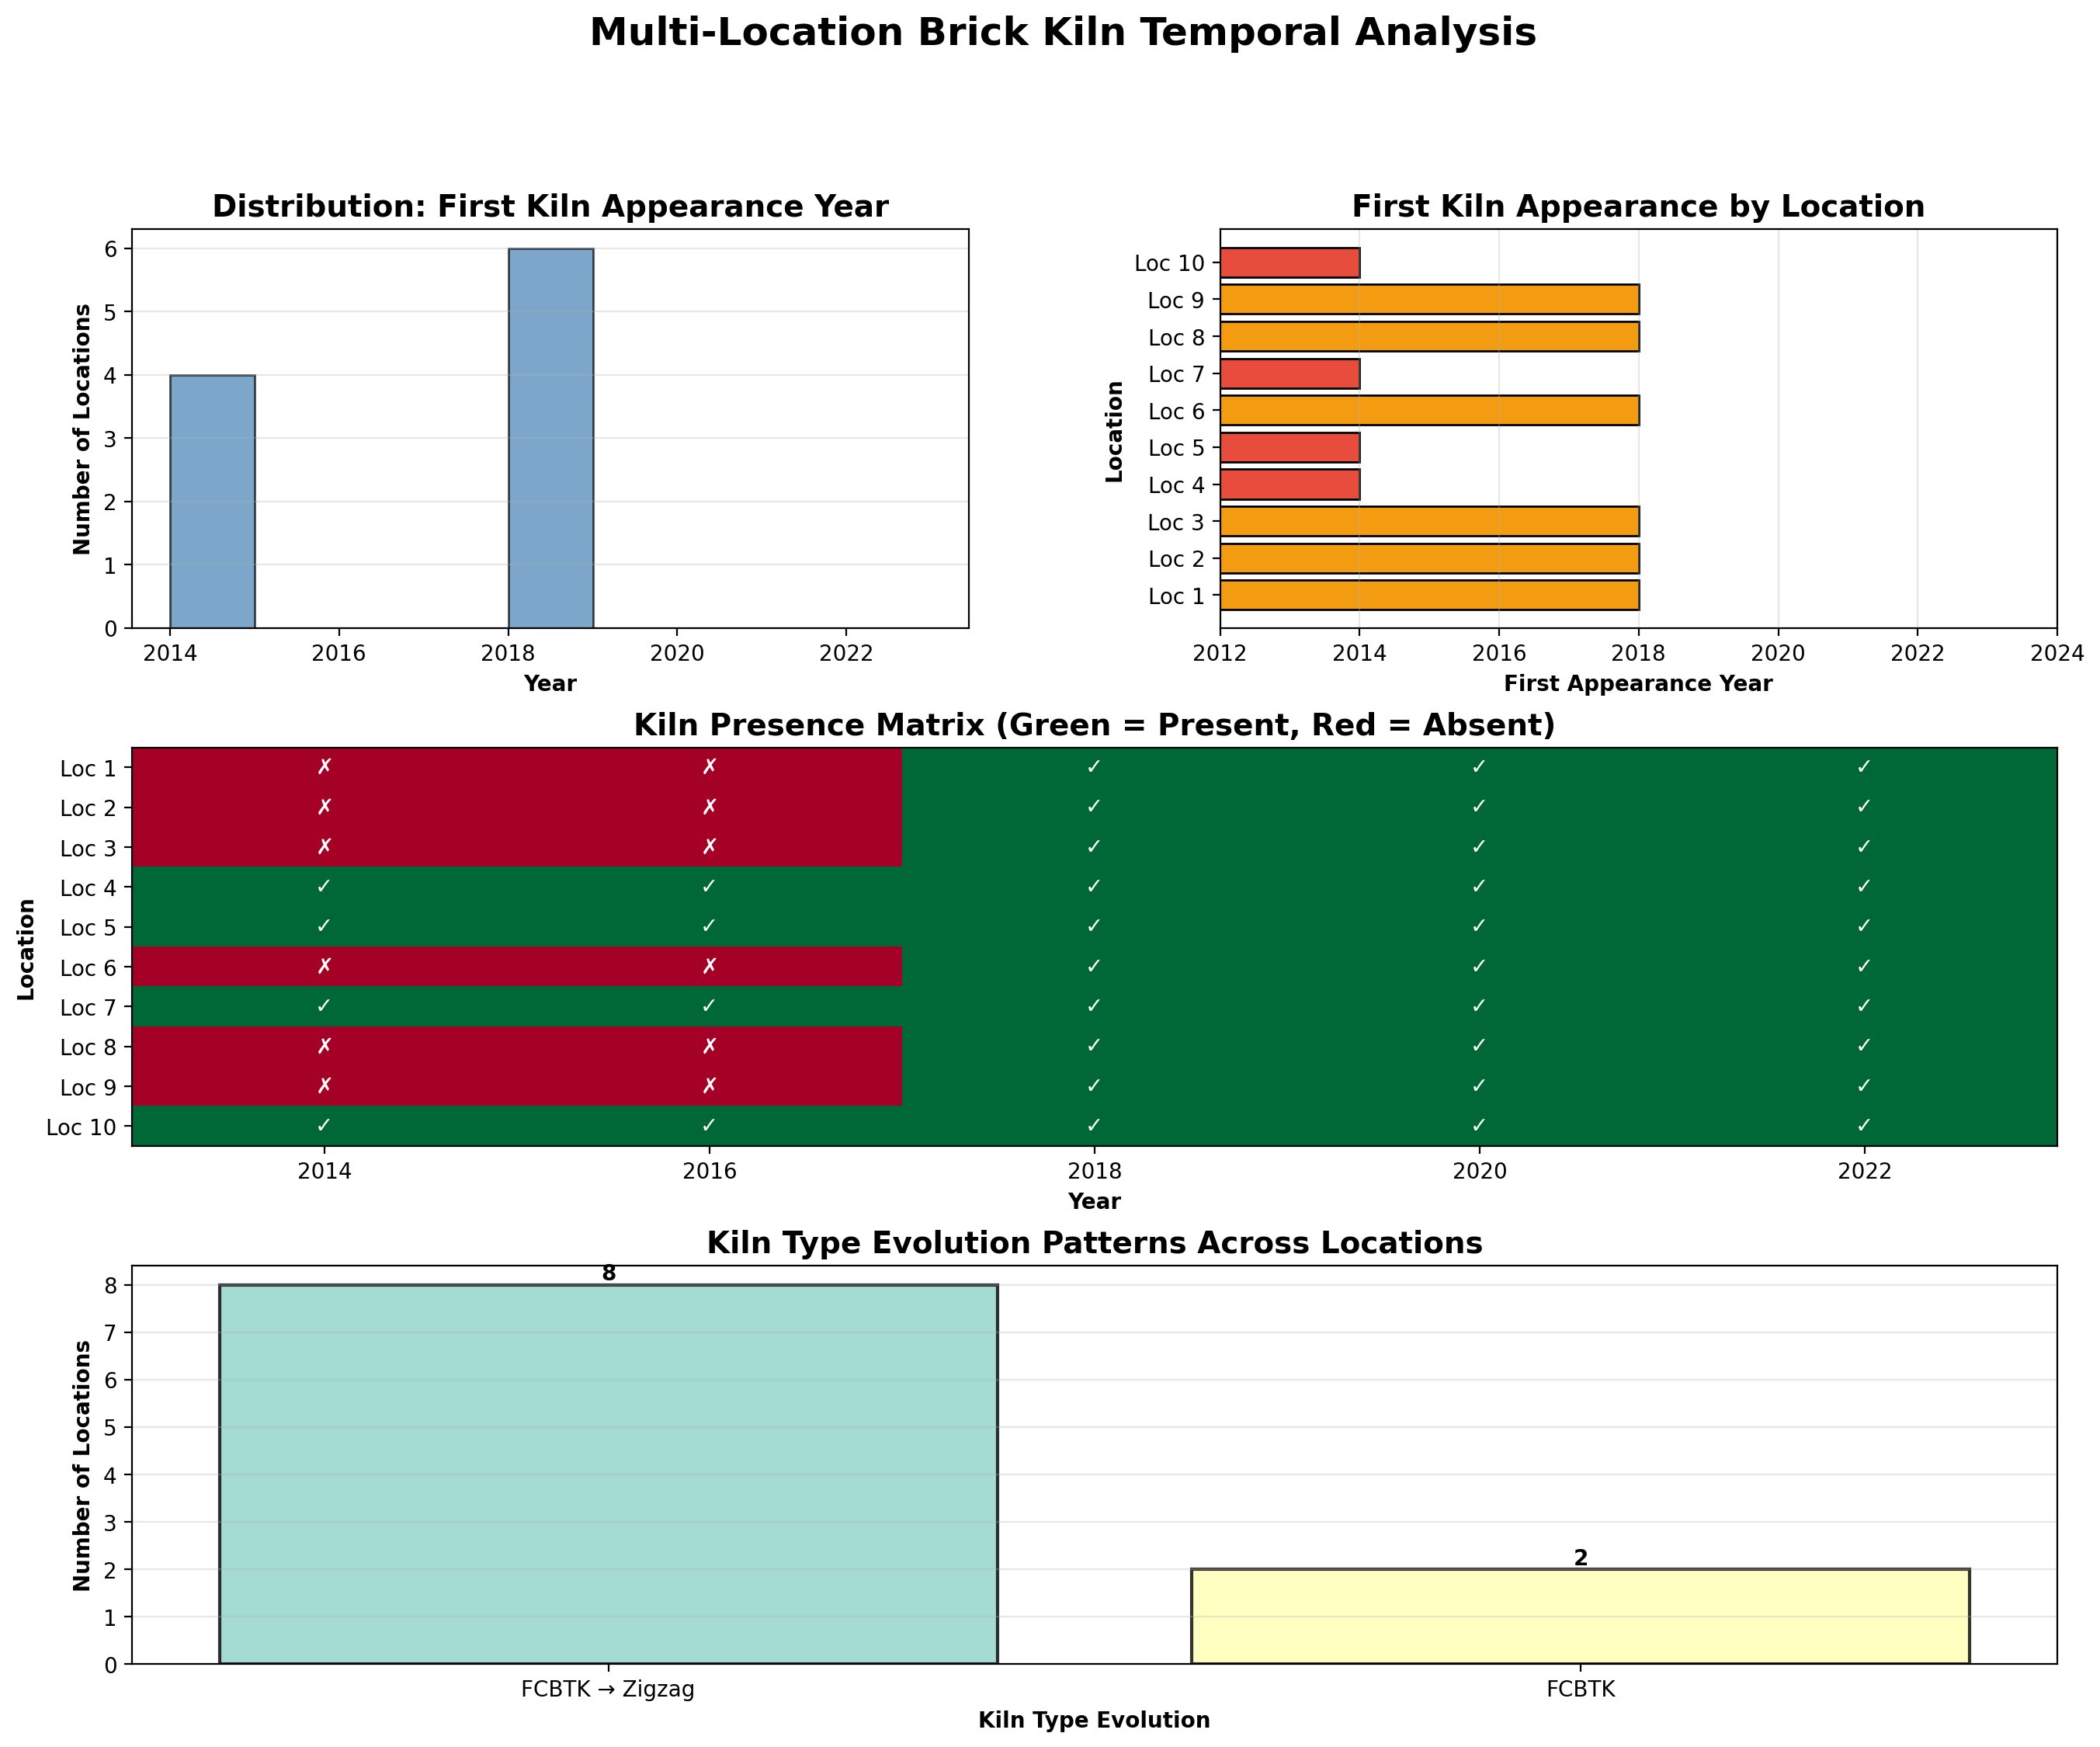

In [26]:
# Prepare data for visualization
first_appearance_years = []
location_labels = []
kiln_evolution_types = []

for i, result in enumerate(all_results, 1):
    if result['analysis']:
        analysis = result['analysis']
        first_year = analysis.get('first_year', None)
        first_appearance_years.append(first_year if first_year else 0)
        location_labels.append(f"Loc {i}")
        
        # Get type evolution (FCBTK → Zigzag)
        year_data = analysis.get('years', [])
        types_seen = [y.get('type', 'None') for y in year_data if y.get('has_kilns')]
        unique_types = list(dict.fromkeys(types_seen))
        kiln_evolution_types.append(' → '.join(unique_types) if unique_types else 'None')

# Create multi-panel visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: First Appearance Year Distribution
ax1 = fig.add_subplot(gs[0, 0])
valid_years = [y for y in first_appearance_years if y > 0]
if valid_years:
    ax1.hist(valid_years, bins=range(2014, 2024), color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Year', fontweight='bold')
    ax1.set_ylabel('Number of Locations', fontweight='bold')
    ax1.set_title('Distribution: First Kiln Appearance Year', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: First Appearance by Location
ax2 = fig.add_subplot(gs[0, 1])
colors_map = {0: 'lightgray', 2014: '#e74c3c', 2016: '#e67e22', 2018: '#f39c12', 
              2020: '#2ecc71', 2022: '#3498db', 2024: '#9b59b6'}
bar_colors = [colors_map.get(y, 'gray') for y in first_appearance_years]
bars = ax2.barh(location_labels, first_appearance_years, color=bar_colors, edgecolor='black', linewidth=1)
ax2.set_xlabel('First Appearance Year', fontweight='bold')
ax2.set_ylabel('Location', fontweight='bold')
ax2.set_title('First Kiln Appearance by Location', fontsize=14, fontweight='bold')
ax2.set_xlim(2012, 2024)
ax2.grid(True, alpha=0.3, axis='x')

# Plot 3: Temporal Matrix - Kiln Presence Across Locations and Years
ax3 = fig.add_subplot(gs[1, :])
years = [2014, 2016, 2018, 2020, 2022]
matrix_data = []

for result in all_results:
    if result['analysis']:
        row = []
        year_data_dict = {y['year']: y for y in result['analysis'].get('years', [])}
        for year in years:
            if year in year_data_dict:
                has_kilns = year_data_dict[year].get('has_kilns', False)
                row.append(1 if has_kilns else 0)
            else:
                row.append(0)
        matrix_data.append(row)
    else:
        matrix_data.append([0] * len(years))

matrix_data = np.array(matrix_data)
im = ax3.imshow(matrix_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax3.set_xticks(range(len(years)))
ax3.set_xticklabels(years)
ax3.set_yticks(range(len(location_labels)))
ax3.set_yticklabels(location_labels)
ax3.set_xlabel('Year', fontweight='bold')
ax3.set_ylabel('Location', fontweight='bold')
ax3.set_title('Kiln Presence Matrix (Green = Present, Red = Absent)', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(len(location_labels)):
    for j in range(len(years)):
        text = ax3.text(j, i, '✓' if matrix_data[i, j] == 1 else '✗',
                       ha="center", va="center", color="white", fontweight='bold')

# Plot 4: Kiln Type Evolution
ax4 = fig.add_subplot(gs[2, :])
type_counts = {}
for evo_type in kiln_evolution_types:
    type_counts[evo_type] = type_counts.get(evo_type, 0) + 1

type_labels = list(type_counts.keys())
type_values = list(type_counts.values())
colors = plt.cm.Set3(range(len(type_labels)))

bars = ax4.bar(type_labels, type_values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax4.set_xlabel('Kiln Type Evolution', fontweight='bold')
ax4.set_ylabel('Number of Locations', fontweight='bold')
ax4.set_title('Kiln Type Evolution Patterns Across Locations', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

plt.suptitle('Multi-Location Brick Kiln Temporal Analysis', fontsize=18, fontweight='bold', y=0.995)
plt.show()

## References

- [Gemini 3 Pro API Documentation](https://ai.google.dev/gemini-api/docs/gemini-3)
- [Async Processing with Gemini API](https://ai.google.dev/gemini-api/docs/async)
- [Multi-Image Context Documentation](https://ai.google.dev/gemini-api/docs/vision)
- [Previous Post: Batch vs Sequential Processing]([posts/2025-12-12-gemini-batch-vs-sequential.ipynb](https://nipunbatra.github.io/blog/posts/2025-12-12-gemini-batch-vs-sequential.html))
- [Brick Kiln Environmental Impact Studies](https://www.cseindia.org/)
- Dataset: Delhi NCR region satellite imagery (2014-2022)